# Author: Tahjae Jackson 
# Description: This notebook serves to execute the staistical analysis of the summary table titled "sample_populatin_frequency"

In [ ]:
# Importing libraries

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu # for statistical testing 

In [ ]:
#  loading dataset

freq_df = pd.read_csv("outputs/sample_population_frequencies.csv")
# freq_df.head()

,sample_id,total_count,population,count,percentage
0,sample00000,93214,b_cell,10908,11.70
1,sample00001,100824,b_cell,6777,6.72
2,sample00002,92822,b_cell,9794,10.55
3,sample00003,93160,b_cell,10081,10.82
4,sample00004,107903,b_cell,4372,4.05


In [12]:
# loading metadata for the sample 

conn = sqlite3.connect("cell_count.db")

samples = pd.read_sql(
    """
    SELECT *
    FROM samples
    """,
    conn
)

# loading the subject metadata

subjects = pd.read_sql(
    """
    SELECT *
    FROM subjects
    """,
    conn
)

# subjects.head()

# samples.head()

In [17]:
#  merging samples and subject table with summary table based on sample id and subject id

analysis_df = freq_df.merge(samples,on="sample_id")
analysis_df = analysis_df.merge(subjects, on="subject_id")
analysis_df.head()

# ensuring that there is no redudancy before filtering
print(analysis_df["condition"].unique())
print(analysis_df["treatment"].unique())
print(analysis_df["sample_type"].unique())
print(analysis_df["response"].unique())

# filtering the data
analysis_df = analysis_df[ (analysis_df["condition"] == "melanoma") & (analysis_df["treatment"] == "miraclib")& (analysis_df["sample_type"] == "PBMC")]
analysis_df.groupby("response")["sample_id"].nunique()


['melanoma' 'carcinoma' 'healthy']
['miraclib' 'phauximab' 'none']
['PBMC' 'WB']
['no' 'yes' None]


response
no     975
yes    993
Name: sample_id, dtype: int64

<Figure size 600x400 with 0 Axes>

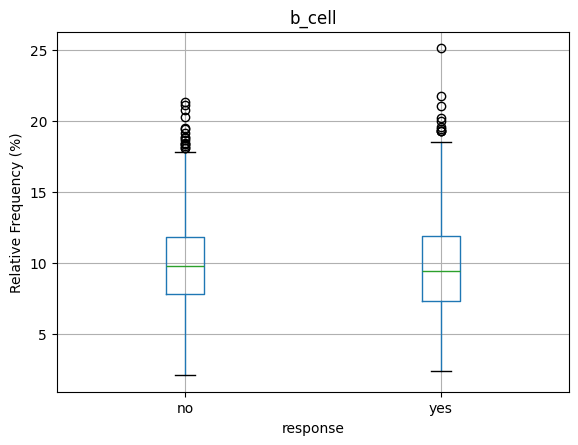

<Figure size 600x400 with 0 Axes>

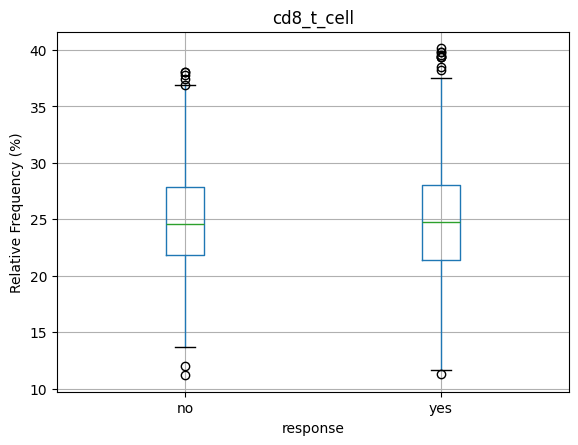

<Figure size 600x400 with 0 Axes>

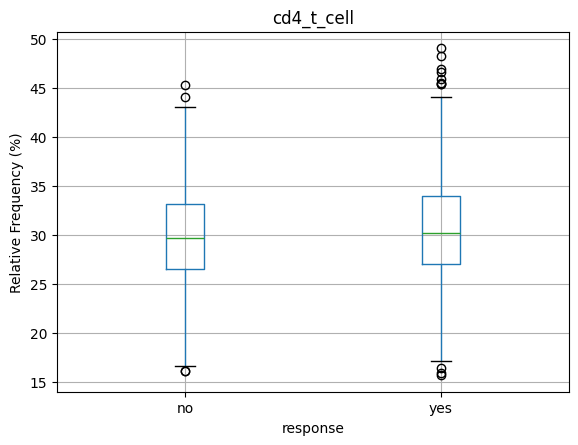

<Figure size 600x400 with 0 Axes>

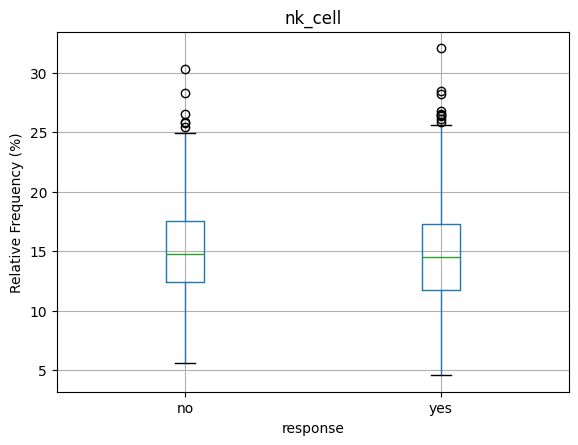

<Figure size 600x400 with 0 Axes>

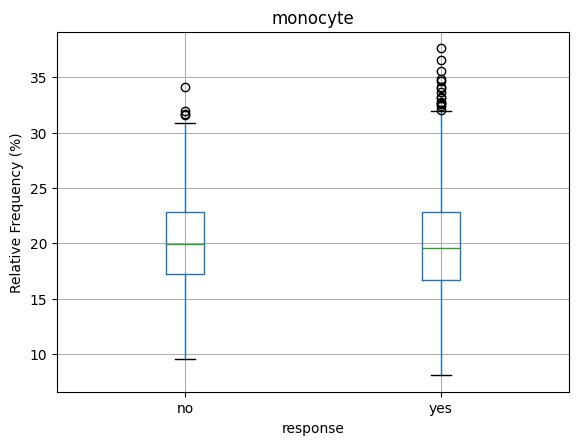

In [18]:
# generating box plot 

# getting list of cell types
populations = analysis_df["population"].unique()

for pop in populations:

    # extracting rows with the same cell type
    subset = analysis_df[analysis_df["population"] == pop]

    # creating box plot
    plt.figure(figsize=(6,4))
    subset.boxplot(
        column="percentage",
        by="response"
    )
    plt.title(pop)
    plt.suptitle("")
    plt.ylabel("Relative Frequency (%)")

    plt.show()

In [22]:
# statistical analysis to support discussion 

results = []

for pop in populations:

    subset = analysis_df[analysis_df["population"] == pop]
    responders = subset[ subset["response"] == "yes"]["percentage"]
    nonresponders = subset[subset["response"] == "no"]["percentage"]

    stat, p = mannwhitneyu(
        responders,
        nonresponders,
        alternative="two-sided"
    ) #set to two-sided because there is no specification of direction 

    results.append(
        {
            "population": pop,
            "p_value": p
        }
    )

results_df = pd.DataFrame(results)
medians = analysis_df.groupby(["population","response"])["percentage"].median()
print(medians)

results_df

population  response
b_cell      no           9.79
            yes          9.43
cd4_t_cell  no          29.66
            yes         30.22
cd8_t_cell  no          24.60
            yes         24.73
monocyte    no          19.94
            yes         19.61
nk_cell     no          14.80
            yes         14.51
Name: percentage, dtype: float64


,population,p_value
0,b_cell,0.055748
1,cd8_t_cell,0.639199
2,cd4_t_cell,0.013407
3,nk_cell,0.121060
4,monocyte,0.163509


CD4 T cells were the only population exhibiting a statistically significant difference between responders and non-responders (Mann-Whitney U, p = 0.013). Responders had a median CD4 T-cell relative frequency of 30.22%, compared with 29.66% for non-responders. While statistically significant, the observed difference was relatively small (0.56 percentage points), suggesting a modest practical effect.